# IRRBB model-risk and business-architecture case study

**Automatically generated from the current Notebook 1 and Notebook 2 artifact contracts.**

| Run field | Value |
|---|---|
| Data source | Federal Reserve GSW SVENY zero-coupon curve (live) |
| Reference date | 2026-07-17 |
| Observations | 1,000 |
| Train / validation / test | 600 / 200 / 200 |
| Dataset fingerprint | `38cad0a67e149b1c…` |
| Report group ID | `9ab3a69f7694905b…` |

This report is intentionally Markdown-only. It is not edited manually after model execution; `build_report.py` regenerates its tables, interpretations and embedded figures from versioned artifacts.

## 1. Why IRRBB is a business problem before it is a curve-fitting problem

IRRBB is the risk to a bank's **capital and earnings** from adverse changes in interest rates. The architecture must cover gap risk, basis risk and option risk across complete contractual and behavioural cash flows. Curve representation is therefore only one controlled component inside governance, data, behavioural modelling, measurement, limits, management action and independent validation.

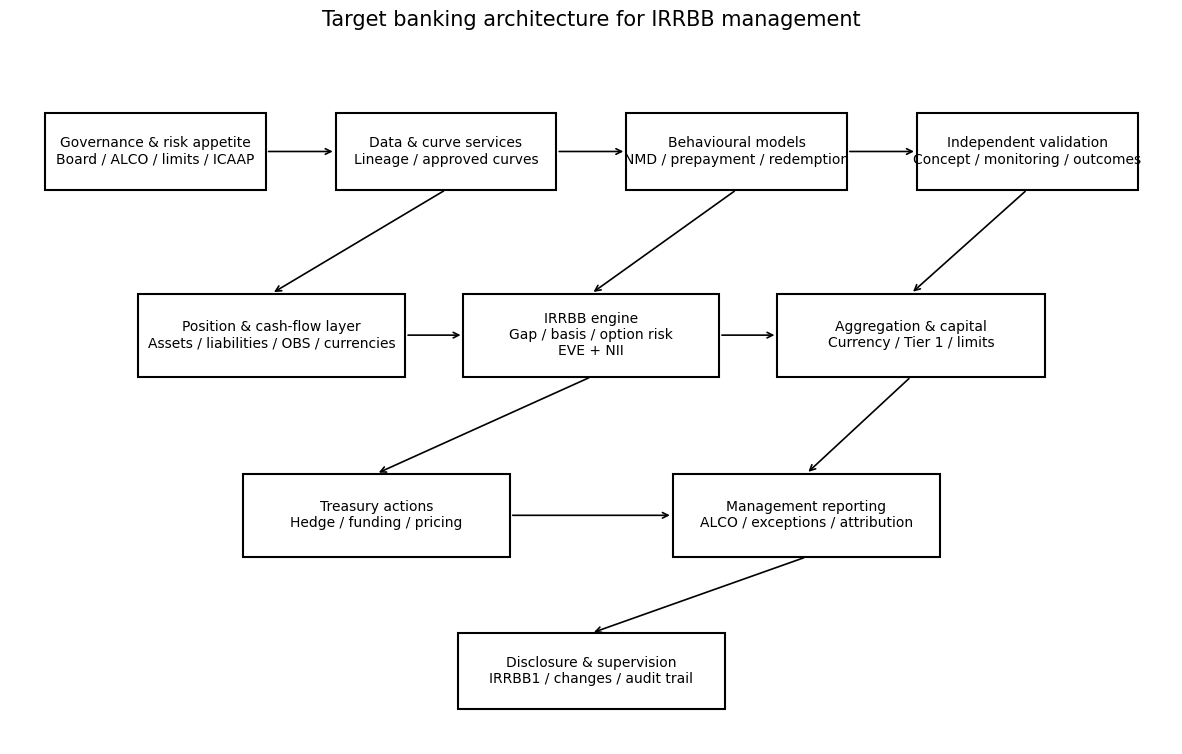

## 2. Target operating and model architecture

The project separates four uses that should not automatically be forced into one model:

1. **Approved valuation curve:** present-value and cash-flow discounting.
2. **Structural factor model:** level, slope and curvature attribution used in risk explanation.
3. **Challenger model:** additional flexibility and model-form challenge.
4. **FTP architecture:** benchmark curve plus funding, liquidity, basis, optionality and regulatory transfer-pricing adjustments.

The two notebooks deliberately feed the same behavioural NMD model, reconciled synthetic banking book, EVE engine, NII engine and prescribed scenario set. This isolates curve-model form as the principal experimental difference.

## 3. Automated analytical workflow and artifact contract

```python
# Notebook 1 and Notebook 2 both write the same contract
artifacts/<model_key>/metrics.json
artifacts/<model_key>/run_manifest.json
artifacts/<model_key>/eve_scenarios.csv
artifacts/<model_key>/nmd_sensitivity.csv
artifacts/figures/<model_key>_*.png
```

The report builder performs four controls before creating this notebook:

- validates required metrics and files;
- verifies SHA-256 hashes in each run manifest;
- requires matching data fingerprints, report-group IDs, dates, sample sizes and Tier 1 inputs;
- regenerates all comparison figures and embeds every PNG as a notebook attachment.

A stale report can therefore no longer be silently combined with newer model outputs.

## 4. Temporal validation design

The common sample is split chronologically:

- **Train:** 600 observations — decay hyperparameter calibration;
- **Validation:** 200 observations — candidate selection;
- **Test:** 200 observations — untouched final evaluation.

PCA is fitted on training-period yield changes and the held-out period is transformed into that frozen PCA space. The daily beta estimates are cross-sectional decompositions of each observed curve after the global decay parameters have been selected; they are not forecasts of future rates.

## 5. Current model results

| Metric | Four-factor Svensson | Three-factor Nelson–Siegel | Current interpretation |
|---|---:|---:|---|
| Test mean RMSE | 2.364 bp | 3.387 bp | Lower is better for reconstruction. |
| Test 95th-percentile RMSE | 4.498 bp | 5.501 bp | Held-out tail fit. |
| Design condition number | 296.7 | 17.1 | NSS is 17.3× more ill-conditioned. |
| Maximum loading correlation | 0.964 | 0.375 | Higher values indicate stronger loading competition. |
| abs(corr(PC1, Δβ0)) | 0.575 | 0.579 | Direct level-factor diagnostic. |
| Mean matched PC–beta correlation | 0.692 | 0.614 | Interpret with dimensionality caveat. |
| Worst ΔEVE / Tier 1 | 14.603% | 14.584% | Current capital sensitivity. |
| ΔNII parallel up | 1.885 mm | 1.885 mm | Earnings response. |
| ΔNII parallel down | -2.482 mm | -2.482 mm | Earnings response. |

The direct PC1–Δβ0 diagnostic does not identify a decisive winner on this run. The matched-factor score must also be interpreted cautiously because the four-factor model can match three PCs against the best three of four betas, whereas all three NS betas participate in the three-by-three assignment.

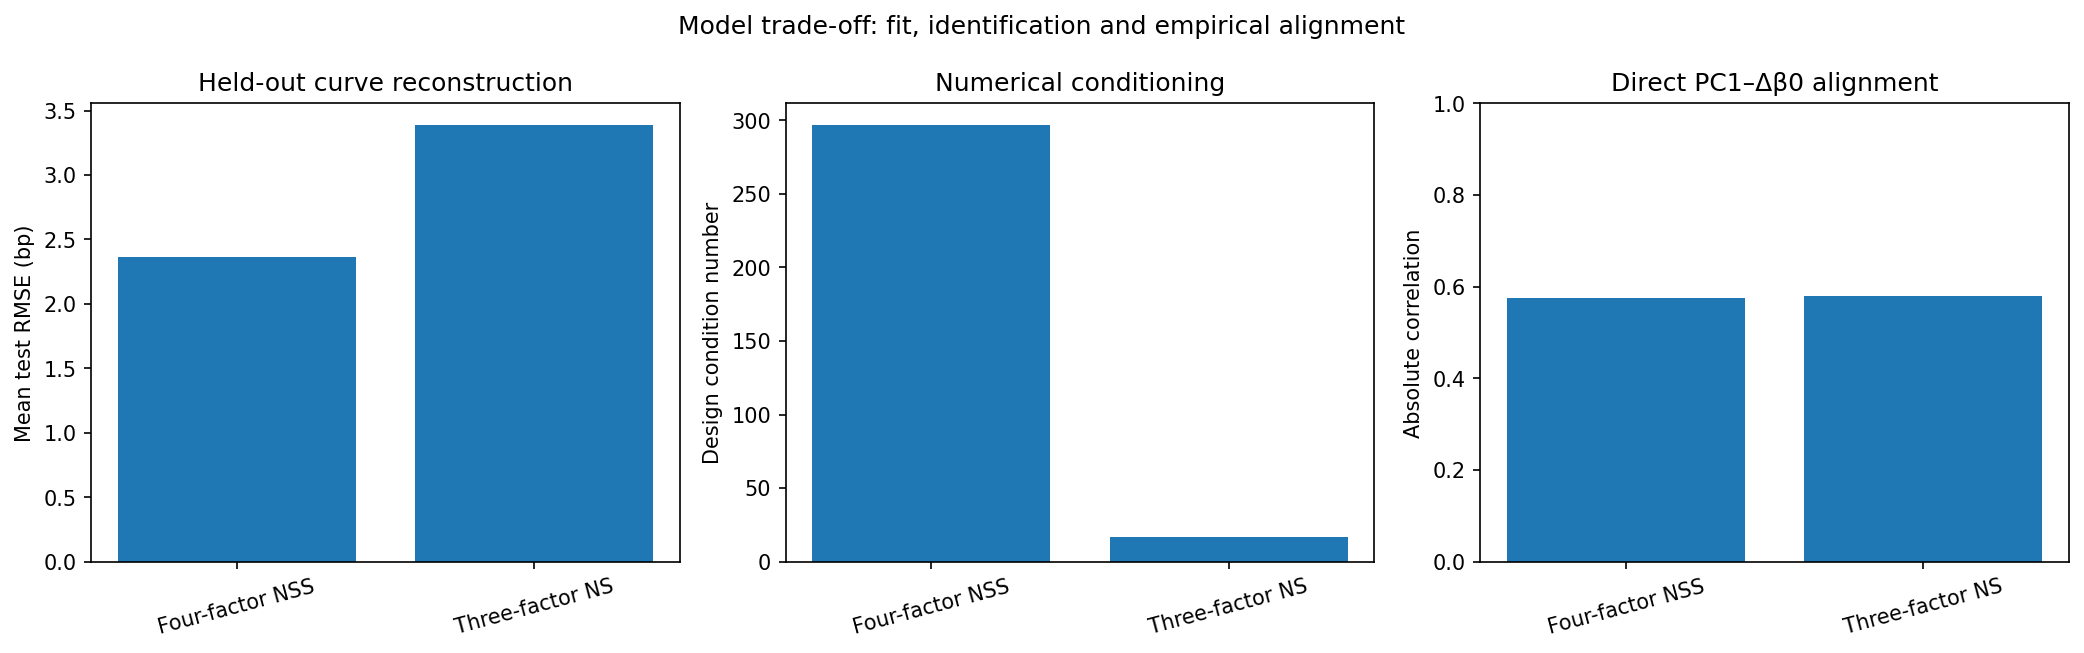

## 6. Diagnostic evidence from each engine

### Four-factor Nelson–Siegel–Svensson

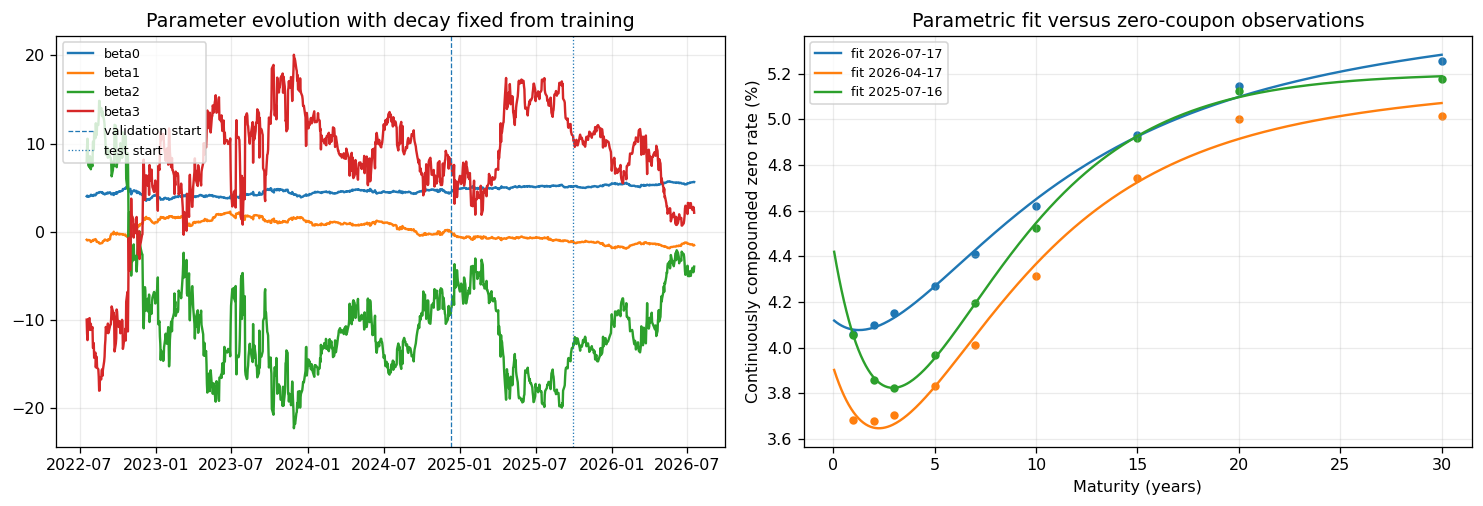

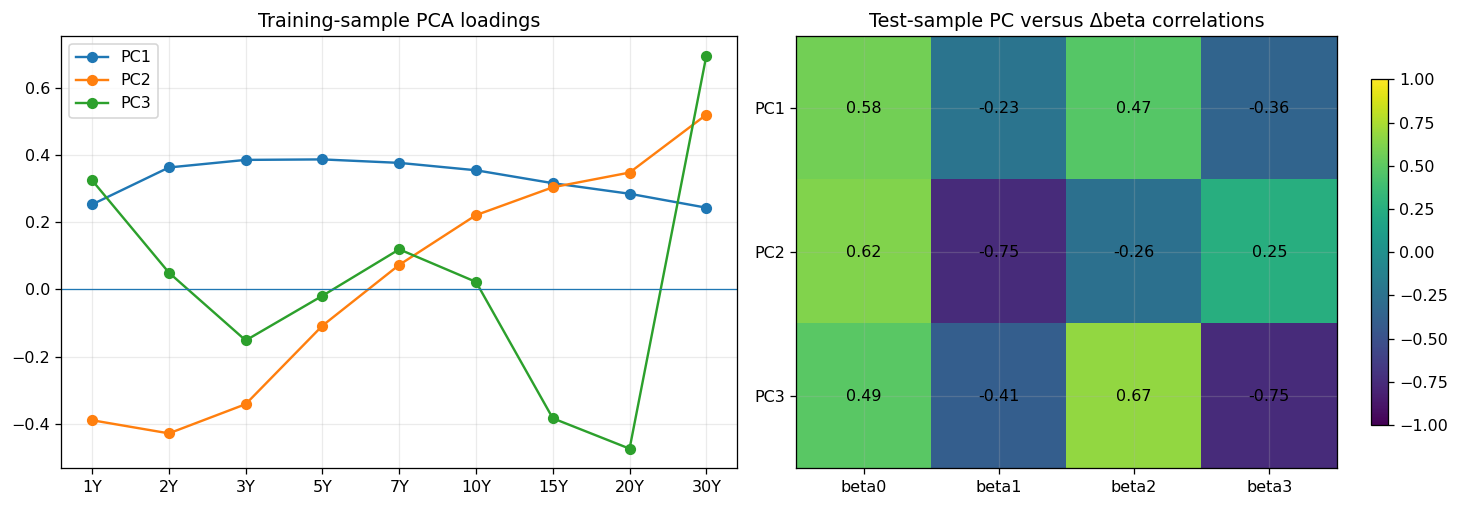

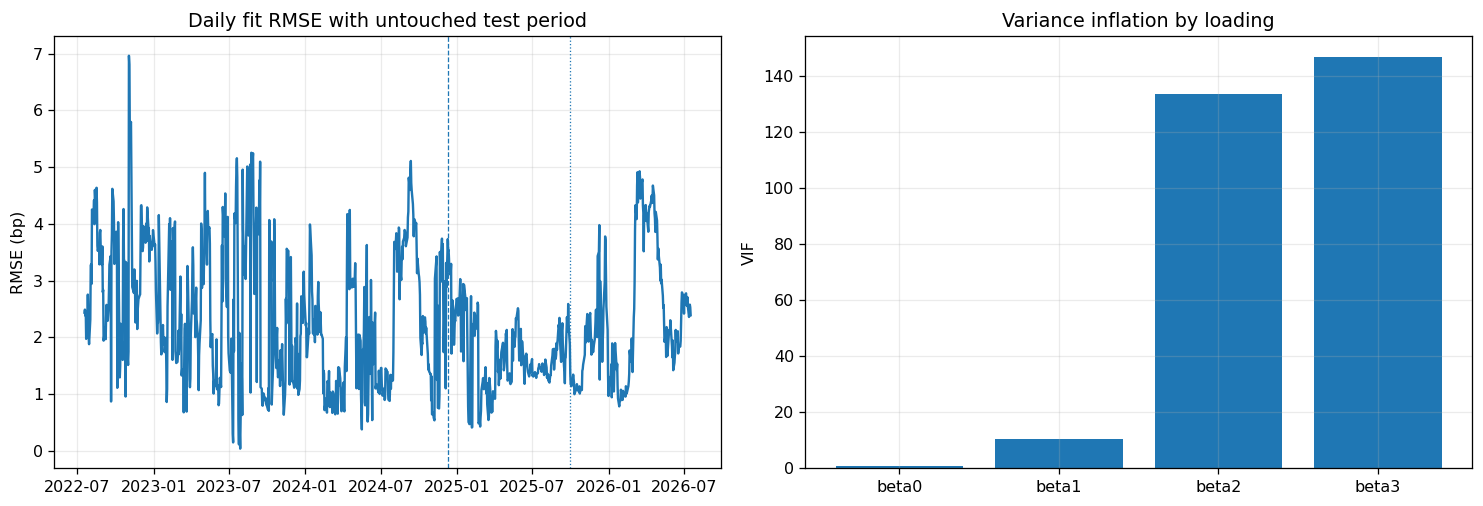

The current NSS run obtains the better held-out curve fit, but the loading matrix is materially less stable. Its reported condition number is **296.7**, versus **17.1** for NS. The individual beta coefficients should therefore not be treated as automatically reliable economic risk factors merely because the reconstructed curve is accurate.

### Three-factor Nelson–Siegel

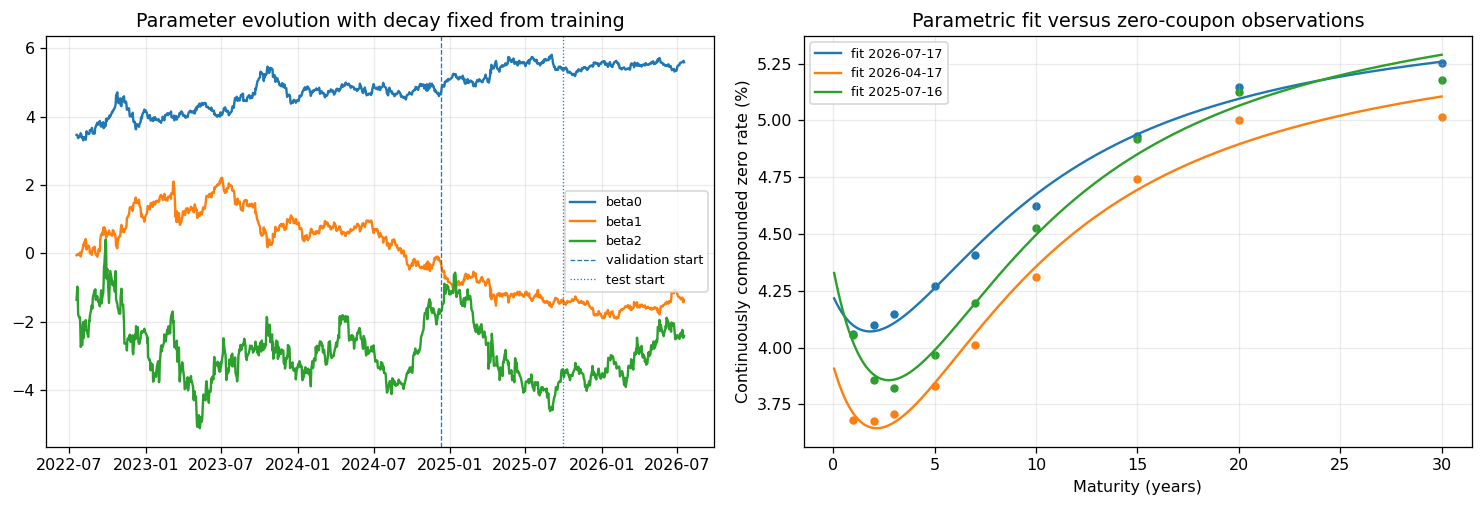

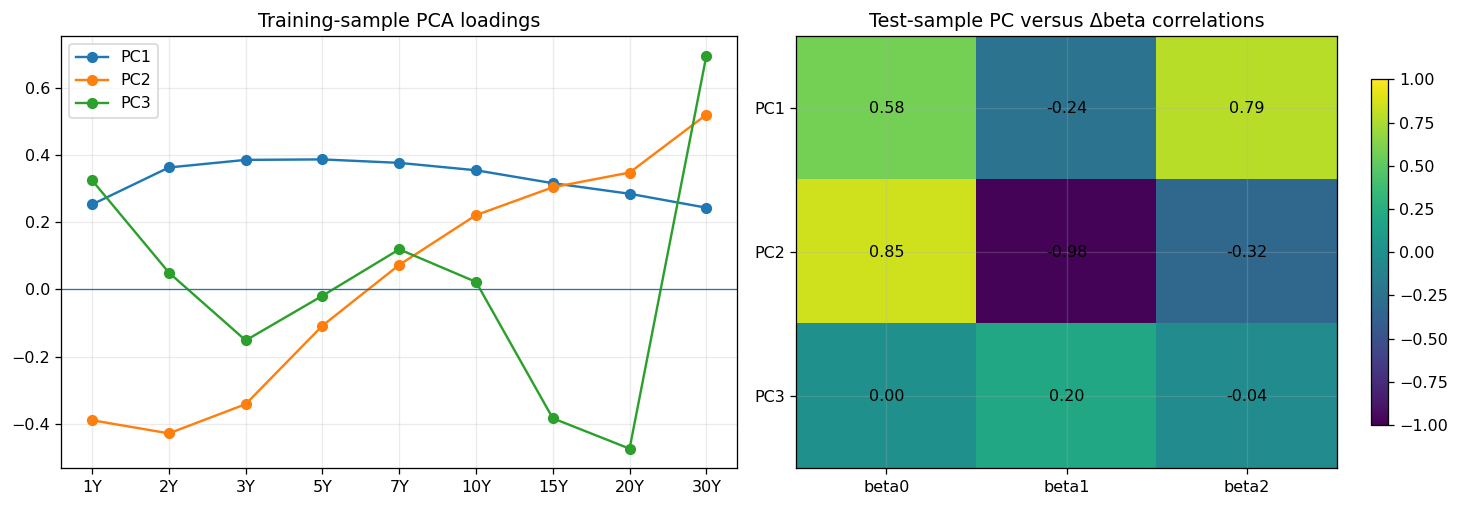

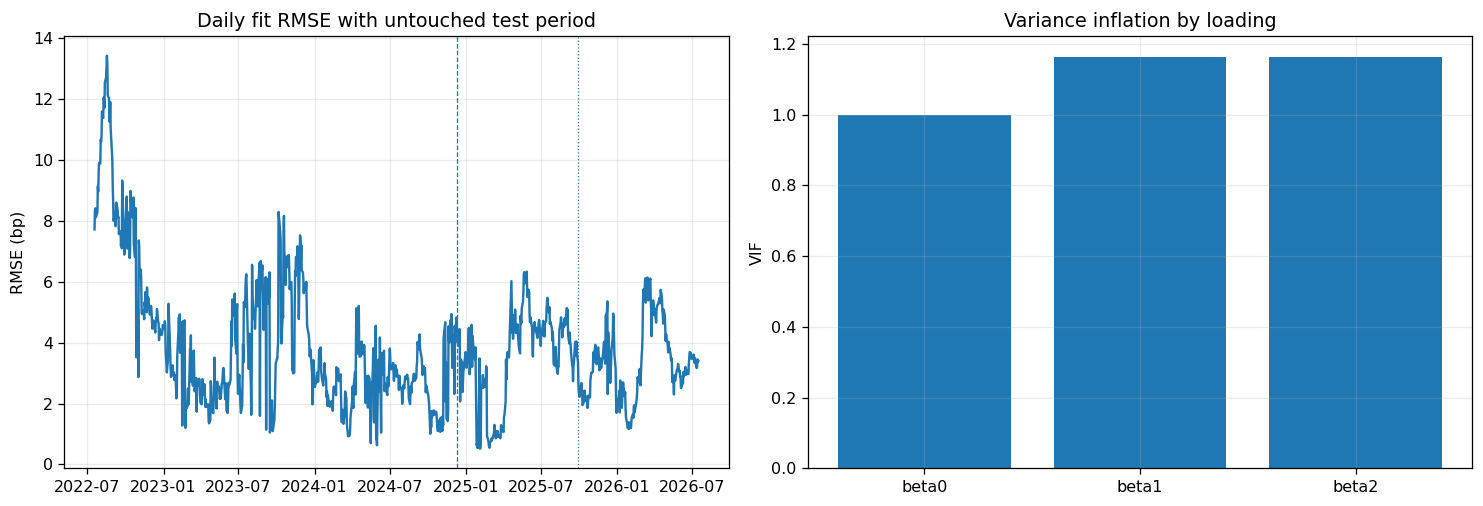

The NS specification accepts a reconstruction penalty in exchange for a much more parsimonious and numerically stable factor basis. The direct PC1–Δβ0 diagnostic does not identify a decisive winner on this run. The matched-factor score must also be interpreted cautiously because the four-factor model can match three PCs against the best three of four betas, whereas all three NS betas participate in the three-by-three assignment.


## 7. EVE, NMD and NII implications

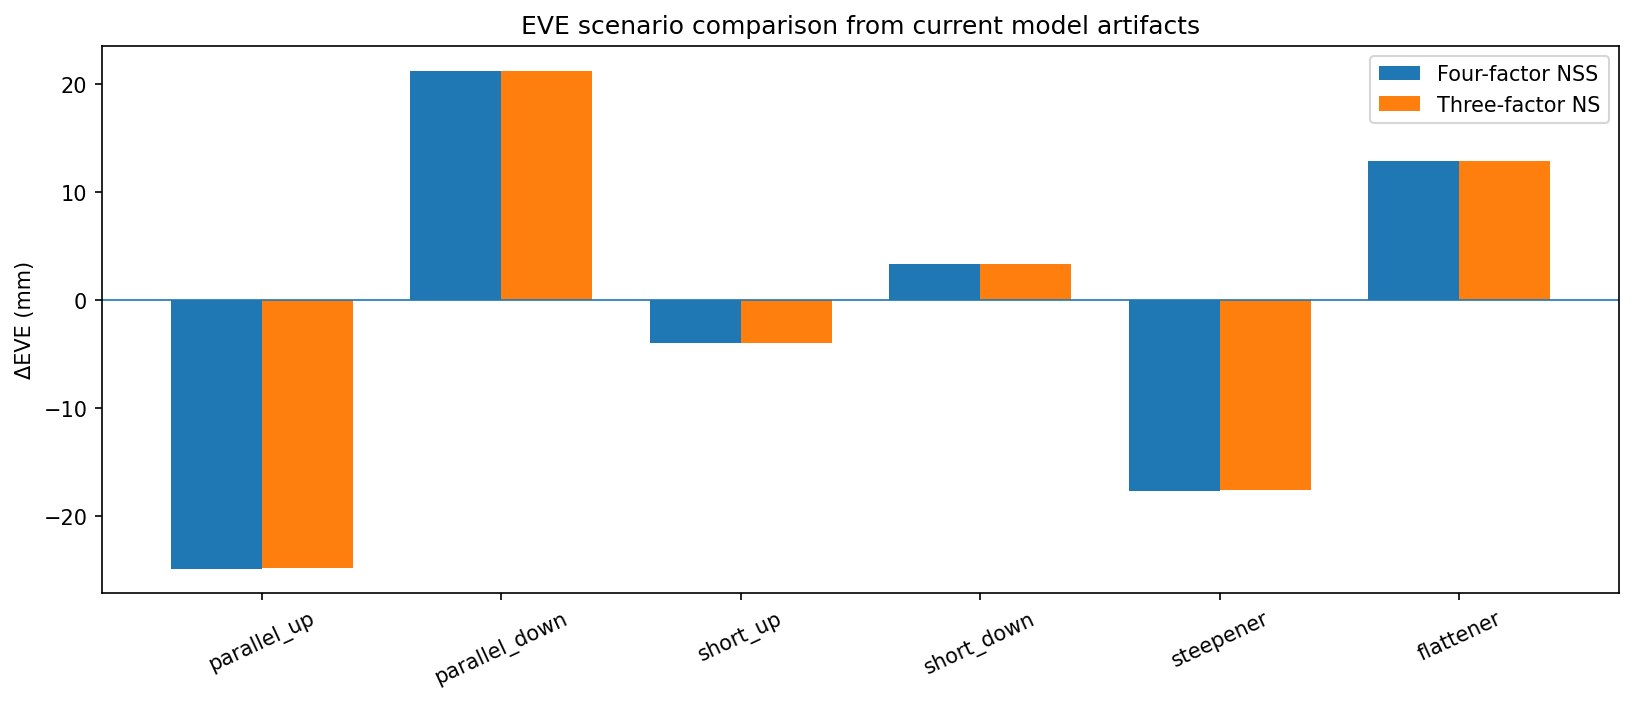

The current worst prescribed scenario is **parallel_up** for NSS and **parallel_up** for NS. Maximum adverse losses are **24.825 mm** and **24.792 mm**, against Tier 1 capital of **170.0 mm**. Their absolute worst-loss difference is only **0.033 mm**.

This does not validate unstable factor coefficients. EVE is a portfolio-level functional of the fitted curve; offsetting coefficients can preserve valuation while weakening attribution and management explanation.

### Behavioural-assumption sensitivity

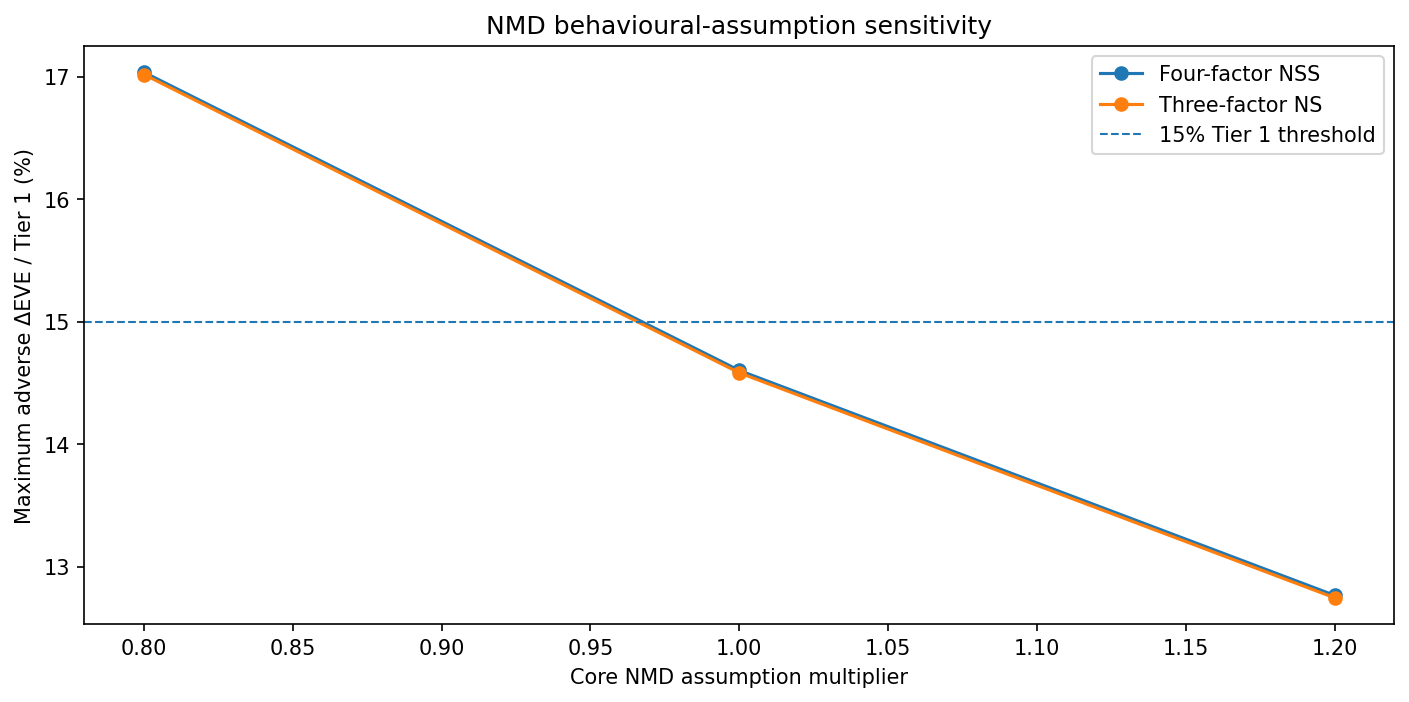

For the NSS run, the 0.8× core-NMD assumption produces **17.035%**, the base assumption produces **14.603%**, and the 1.2× assumption produces **12.769%**. The behavioural NMD assumption therefore has a much larger capital effect than the difference between the two curve representations.

### NMD and earnings architecture

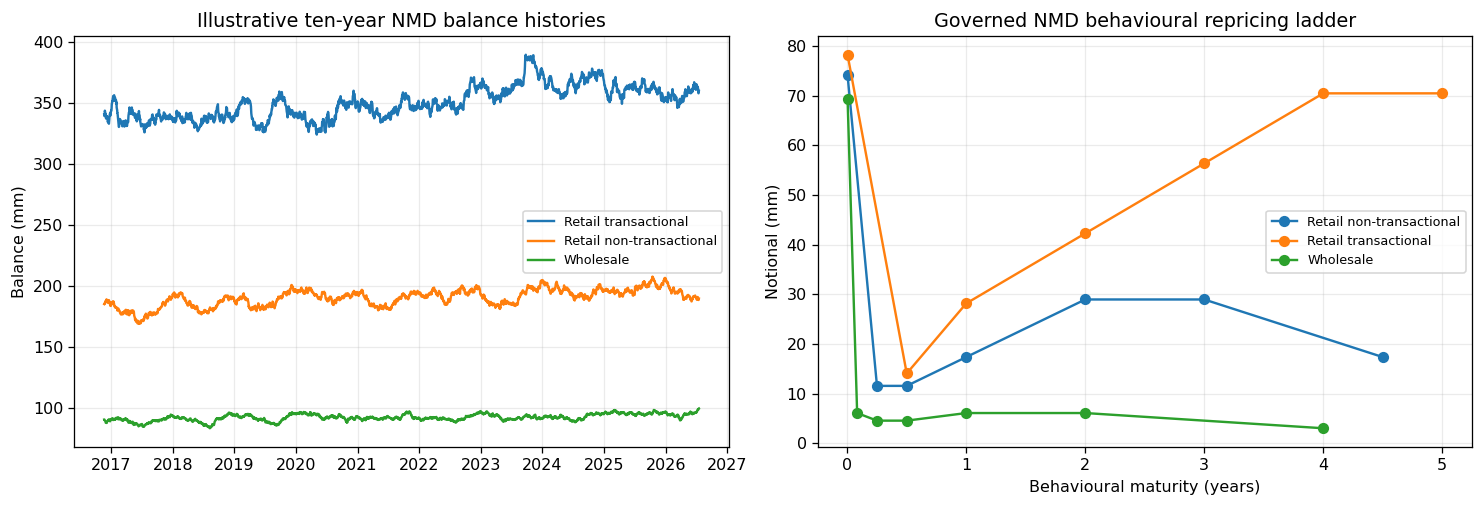

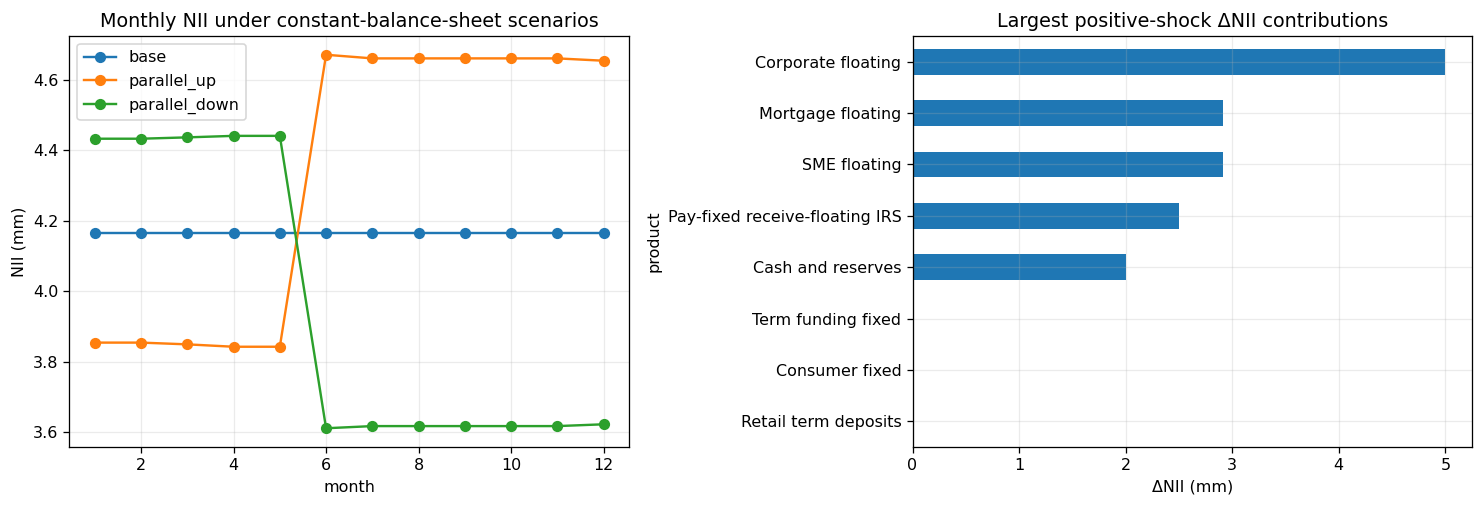

The parallel-shock ΔNII figures are driven principally by contractual repricing, deposit betas, lags and hedging. The small difference in base NII across curve models is distinct from the shocked-minus-base earnings sensitivity.

## 8. Model-risk decision

The four-factor NSS model reduces mean test RMSE by **1.023 bp** (**30.2%** relative to NS), but its design matrix is **17.3×** more ill-conditioned. The defensible architecture is therefore use-case specific: retain NSS as a flexible reconstruction/valuation challenger, and use the three-factor NS model as the parsimonious structural benchmark for governance and attribution unless additional evidence demonstrates stable incremental value from the fourth factor.

### Governance assignment

| Use case | Recommended role |
|---|---|
| Curve reconstruction / valuation challenge | Four-factor NSS challenger |
| Structural benchmark and management attribution | Three-factor NS benchmark |
| Final discounting curve | Separate approved market-data/curve service |
| FTP | Separate curve stack with liquidity, funding, basis and optionality components |

The recommendation is conditional on the current artifacts. If later runs change the fit, conditioning, factor-alignment or downstream materiality evidence, this section is regenerated automatically rather than preserving a stale conclusion.

## 9. Limitations and production requirements

This remains a portfolio-grade research prototype. A bank production implementation would require approved instrument-level curve construction, full product cash-flow conventions, account-level NMD and option models, basis-risk architecture, dynamic-balance-sheet NII, multi-currency/legal-entity aggregation, independent implementation validation, data lineage, access controls, monitoring and formal model-governance approval.

## 10. Reproducibility, lineage and references

### Source artifacts

- `artifacts/nss4/metrics.json` and `run_manifest.json`
- `artifacts/ns3/metrics.json` and `run_manifest.json`
- model-specific CSV tables and PNG diagnostics
- comparison figures regenerated by `build_report.py`

The report was built only after the two manifests matched on dataset fingerprint `38cad0a67e149b1c…`, report-group ID `9ab3a69f7694905b…`, reference date **2026-07-17**, sample sizes and Tier 1 capital.

### References

1. Basel Committee on Banking Supervision, **SRP31 — Interest rate risk in the banking book**, effective 1 January 2026.
2. Basel Committee on Banking Supervision, **Recalibration of shocks for IRRBB**, 16 July 2024.
3. Basel Committee on Banking Supervision, **SRP98 — Application guidance on IRRBB**.
4. Basel Committee on Banking Supervision, **DIS70 — IRRBB disclosure requirements**.
5. Federal Reserve Board, **Gürkaynak–Sack–Wright nominal yield-curve data**.
